In [3]:
import numpy as np
import pandas as pd
import altair as alt
import altair_viewer
import statsmodels.api as sm
from scipy import linalg
from statsmodels.multivariate.pca import PCA
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

alt.data_transformers.disable_max_rows()
alt.renderers.enable('mimetype')

RendererRegistry.enable('mimetype')

In [4]:
fertility = pd.read_csv('data/fertility.csv')
country = pd.read_csv('data/country-indicators.csv')
gender = pd.read_csv('data/gender-data.csv')

# Analysis of Fertility Rates
Alice Zhang 

## Abstract
My project investigates the decline in fertility rates across select developed nations in the 20th century and seeks to identify key drivers of this decrease. To this end, I will conduct an in-depth analysis of gender, country, and socioeconomic indicators in Python, applying various techniques to address my research questions.  

Due to the relatively small size of our dataset, the findings may not be generalizable to all countries. Furthermore, limiting the analysis to data from 2018 restricts our scope and ability to capture temporal trends over time. The analysis may also be subject to biases due to missing data, and we acknowledge that not all potential confounding factors are accounted for in this study.


## Introduction

### Background


Over the last 50 years, the global fertility rate has halved. Modernization and technological advancements were coupled with a stark decline in fertility rates, while population growth surged. This rapid growth was expected to plateau as fertility rates – measured as the average number of children per woman – continued to decline. As of 2021, the global fertility rate is 1.66 and [falling](https://www.cbo.gov/publication/58912#:~:text=In%20CBO's%20projections%2C%20the%20total,where%20it%20remains%20through%202053). 

[Current perspectives](https://ourworldindata.org/fertility-rate#data-sources)  attribute this decline to factors such as women’s social mobility, economic stability, and improvements in child well-being. This project seeks to explore:
* Which factors most predict a country’s fertility rate?
* How do upward mobility, economic prosperity, and child well-being impact fertility rates?
* Which of these explanations are the most probable?

### Sources
The data used in this project are sourced from
* [United Nations Development Programme](https://www.undp.org/) 
* [World Bank](https://data.worldbank.org/)
* Preprocessed datasets from [lab06](https://github.com/ucsb-ds/pstat100-content/tree/main/labs/lab6-regression/data). 

### Motivation

From an economic standpoint, improved welfare is expected to *increase* fertility rates. Modernization has largely enhanced reproductive success by improving access to resources like immunizations, which help reduce mortality. The pre-modern era, characterized by high mortality rates and widespread disease, had higher fertility rates than today. 

This begs the question: Was fertility simply a matter of scarcity? Or did reproduction hold more value due to limited opportunities for women?

Modern research also explores the impact of social mobility on fertility. As modernization progresses, women are becoming more career-oriented, narrowing the wage gap and breaking through the glass ceiling. Does upward social mobility and shifting social norms lead women to reject traditional gender roles such as childbearing?

This project examines these socioeconomic factors to provide insight into how modernization, economic prosperity, and shifting gender roles influence fertility trends in the 21st century.

### Data Description

This project utilizes datasets that measure human development, gender development, and world development indices across various countries. The data is sourced from the Human Development Index (HDI), Gender Development Index (GDI), and World Development Index (WDI), with a focus on indicators relevant to fertility rate analysis.

We specifically examine the following variables:
* GDP per capita: The total economic output of a country, adjusted for population size, measured in current U.S. dollars.
* Immunization rate: The percentage of children aged 12-23 months who have received DPT (diphtheria, pertussis, and tetanus) and measles vaccinations.
* Life expectancy at birth: An indicator of health that reflects the average number of years a newborn is expected to live, assuming age-specific mortality rates remain constant.
* Expected years of schooling: The total number of years of schooling that a child of school-entry age can expect to receive, assuming age-specific enrollment ratios remain unchanged.
* HDI (Human Development Index): A composite index measuring a country's achievements in health (life expectancy), education (mean and expected years of schooling), and standard of living (GNI per capita).
* GDI (Gender Development Index): An index measuring gender inequalities in human development, considering health, education, and economic resources (such as earned income).

The HDI is calculated as the geometric mean of normalized indices for each of these three dimensions, while the GDI adjusts for gender inequalities within these areas. Detailed technical notes on the calculation of these indices can be found [here](https://hdr.undp.org/system/files/documents/technical-notes-calculating-human-development-indices.pdf). 

**Data on social mobility** is partially represented through education level, which serves as a proxy for career opportunities and social status. Education correlates strongly with economic mobility and can indicate access to better jobs and career stability. Although unemployment data is also a potential indicator of social mobility, it was excluded due to high levels of missing data.

**Sampling design and methods**: The datasets used in this analysis are sourced from reputable organizations, including the United Nations Development Programme (UNDP) and the World Bank. While the sampling methods and data sources are assumed to be reliable, some limitations exist, such as data reporting errors and translation inaccuracies may occur when normalizing measurements. These issues could affect the representativeness of the variables included in our analysis.

#### Variable Description

The variables we'll be exploring include: 

Dataset | Name | Variable | Units
---|---|---|---
`fertility` | `fertility_total` | National fertility rate | Average number of children per woman
`country` | `gdp_percap` | GDP per capita | current U.S. dollars
`country` | `immunization` | Average immunization rate| Percentage (value 1-100)
`country` | `gdi` | Gender development index | Index between 0 and 1 (0 is lowest, 1 is highest)
`country` | `hdi` | Human development index | Index between 0 and 1 (0 is lowest, 1 is highest)
`gender` | `edu_expected_yrs_f` | Expected years of education for adult women | Years
`gender` | `life_birthf` | Life expectancy at birth, female (years) | Years


### Project Roadmap

The project begins with data processing, where we tidy datasets, extract relevant variables, and address missing values. Next, we perform exploratory data analysis (EDA), applying statistical analysis techniques to uncover trends, relationships, and variability. We then build a multiple regression model to address our research questions, performing necessary data transformations to ensure valid analysis. Multiple visualization will be created throughout the process to facilitate interpretation and comparative analysis. The project concludes with a summary of key findings, offering insights into the primary drivers of fertility rate trends in developed nations.


## Data Tidying

We start by extracting relevant variables from 3 datasets: fertility, gender, and country-level indicators.  The datasets are then merged on country names, using an inner join to combine fertility and gender indicators and a left join to include country-level data. The final dataset is indexed by country and missing values are removed to ensure completeness. 

Here is a preview of the final dataset (first 4 rows).

In [5]:
# extract variables of interest
fertility_sub = fertility.loc[:, ['Country', 'fertility_total']] 
gender_sub = gender.loc[:, ['educ_expected_yrs_f', 'life_birthf', 'Country']] 
country_sub = country.loc[:, ['Country', 'hdi', 'gdi', 'gdp_percap', 'immunization']]

# merge datasets 
data = pd.merge(    # merge fertility and gender indicators
    fertility_sub,
    gender_sub,
    on = 'Country',    # join on country name (inner join)
    how = 'inner'    
).merge( 
    country_sub,     # merge country indicators (left join)
    on = 'Country', 
    how = 'left'   
).set_index('Country').dropna()  # drop all rows w/ NA's 

data.head(4) # preview the data 

,fertility_total,educ_expected_yrs_f,life_birthf,hdi,gdi,gdp_percap,immunization
Country,,,,,,,
Afghanistan,4.473,6.795722,66.026,0.509,0.663,493.750418,65.0
Albania,1.617,13.201755,80.167,0.792,0.971,5284.380184,96.5
Algeria,3.023,12.108990,77.938,0.746,0.860,4153.733978,85.5
Angola,5.519,6.973901,63.666,0.582,0.903,3289.646664,56.5


## Exploratory Data Analysis

In this section, we will conduct exploratory analysis of the dataset, applying statistical analysis and data visualization techniques to explore trends, identify relationships, and infer causality.

We begin with correlation analysis to examine relationships between different variables, followed by principal component analysis (PCA) to identify key drivers of variability. Throughout, we will create multiple visualizations to highlight key trends and findings. 

### Correlation Analysis

First, we'll examine the correlation matrix for the data to get a sense of which variables tend to vary together.

 The correlation matrix is a matrix of all pairwise correlations between variables, with values ranging from -1 to 1.  A correlation value of 1 indicates a perfectly positive relationship, while a value of -1 suggests the inverse.
 
 These values provide insight into the strength and direction of relationships, helping us identify hidden patterns and detect potential issues such as multicollinearity. 


In [6]:
corr_mx = data.corr()    # create correlation matrix 
corr_mx  # view correlation matrix

,fertility_total,educ_expected_yrs_f,life_birthf,hdi,gdi,gdp_percap,immunization
fertility_total,1.000000,-0.860730,-0.864710,-0.860446,-0.667698,-0.493784,-0.599602
educ_expected_yrs_f,-0.860730,1.000000,0.828196,0.882125,0.711611,0.518237,0.625988
life_birthf,-0.864710,0.828196,1.000000,0.929450,0.613698,0.626654,0.626974
hdi,-0.860446,0.882125,0.929450,1.000000,0.652496,0.716262,0.579950
gdi,-0.667698,0.711611,0.613698,0.652496,1.000000,0.362602,0.538089
gdp_percap,-0.493784,0.518237,0.626654,0.716262,0.362602,1.000000,0.344651
immunization,-0.599602,0.625988,0.626974,0.579950,0.538089,0.344651,1.000000


Most of our variables are positively correlated, though their strengths vary. 

Key observations: 

* Lower fertility rates are strongly correlated with education, life expectancy, and HDI (-0.86), suggesting that improvements in these socio-economic factors reduce fertility.
* Education, life expectancy, and HDI show a strong positive correlation (0.83-0.93), indicating they tend to improve together.
* GDP per capita has a moderate negative correlation with fertility (-0.49), suggesting economic growth impacts fertility less than social factors.
* Immunization rates are moderately correlated with fertility (-0.60) and strongly with education and life expectancy (0.63).
* Gender equality (GDI) is moderately negatively correlated with fertility (-0.67).

The strong correlations among socioeconomic indicators points to potential multicollinearity, which may require feature selection or dimensionality reduction in later steps.

Below, I've generated a heatmap to visualize these relationships.

In [7]:
# melt corr_mx
corr_mx_long = corr_mx.reset_index().rename(   # move index to a column 
    columns = {'index': 'row'}).melt(  # renames index to "row"
    id_vars = 'row',      
    var_name = 'col', 
    value_name = 'Correlation'      # converts wide format to long format 
) 

# construct the plot 
alt.Chart(corr_mx_long).mark_rect().encode(   # create a heatmap 
    x = alt.X('col', title = '', sort = {
        'field': 'Correlation', 'order':'ascending'}),  # create x and y axis 
    y = alt.Y('row', title = '', sort = {
        'field': 'Correlation', 'order':'ascending'}),   # sort by correlation values in ascending order  
    color = alt.Color('Correlation', 
                      scale = alt.Scale(
                          scheme = 'blueorange', 
                          domain = (-1, 1), 
                          type = 'sqrt'), 
                      legend = alt.Legend(tickCount = 5))    # define chart properties 
).properties(
    width = 300, 
    height = 300)

<VegaLite 5 object>

If you see this message, it means the renderer has not been properly enabled
for the frontend that you are using. For more information, see
https://altair-viz.github.io/user_guide/display_frontends.html#troubleshooting


### Principal Components Analysis

A key preliminary step to data modeling is dimensionality reduction: analyzing the dataset to assess its correlation structure and extracting insights to inform further analysis. 

One such method is Principal Component Analysis (PCA): A technique that reduces dimensionality by selecting components that capture the most variance and excluding those with weaker effects. This allows us to simplify the model and focus on the most important features.

The core technique of PCA is finding linear data transformations that preserve variance. Each principle component (PC) is a linear combination (LC) of the form: 

$$
\text{PC} = \mathbf{Xv} = v_1 \mathbf{x}_1 + v_2 \mathbf{x}_2 + \cdots + v_p \mathbf{x}_p
$$

where 
- **$\mathbf{X}$** is the data matrix.
- **$\mathbf{v}$** is the vector of **loadings**  (weights or coefficients used in the LC) 

In this section, we'll apply PCA to identify the components that capture the most variance in our dataset, providing insight into its underlying structure to guide further analysis and modeling.

#### Compute Principal Components

In `statsmodels`, the module `multivariate.pca` contains an easy implementation for computing our principal components. 

Many relevant quantities can be retrieved as attributes, such as loadings (weights), scores (values of each linear combination), and eigenvalues of the correlation matrix.

In [8]:
# compute principal components
pca = PCA(data, standardize = True)

#### Variance Ratios

Variance ratios quantify the proportion of total variation captured by each PC. These are computed from the eigenvalues of the correlation matrix, with components ranked in order of descending variance. 

In [9]:
var_ratios = pca.eigenvals/pca.eigenvals.sum() # compute variance ratios

var_ratios  # display

0    0.721384
1    0.108046
2    0.069401
3    0.055937
4    0.021705
5    0.017333
6    0.006194
Name: eigenvals, dtype: float64

The first PC captures 72% of total variation, indicating a strong dominant pattern where a specific linear combination of factors likely explain fertility rates. The variables with the highest loadings on this component are key drivers of variability. 

This insight guides our next steps: identifying *which* factors are most influential in driving this primary component. 

#### Inspect Loadings

Now that we've identified the primary PC (PC1), we turn to inspect its loadings. 

Loadings are weights with which each variable contributes to PC1. A higher absolute value of the loading indicates that the variable strongly influences the PC, indicating a stronger effect on variation. 

In [10]:
# store variance ratios in a dataframe
pca_var_explained = pd.DataFrame({
    'Component': np.arange(1, len(var_ratios)+1),
    'Proportion of variance explained': var_ratios})

# extract first PC 
first_pc = pca.loadings.iloc[:, 0].values   # extract loadings
var_explained = var_ratios[0]    # proportion of variance captured by PC1

# display results 
print('number selected: ', 1)
print('proportion of variance captured: ', var_explained)

number selected:  1
proportion of variance captured:  0.7213844434872565


In [11]:
#  subset loadings
loading_df = pca.loadings.iloc[:, [0]]   # select loadings for PC1

# rename columns
loading_df = loading_df.rename(columns={'PC1': 'Loading'})

loading_df.head()   # print results 

,comp_0
fertility_total,-0.407364
educ_expected_yrs_f,0.412409
life_birthf,0.416766
hdi,0.425914
gdi,0.340855


These findings indicate that PC1 is primarily driven by positive loadings from education, life expectancy, HDI, and GDI. These are key drivers of variability in our dataset. 

The negative loading on fertility suggests an inverse relationship, where higher development and education levels correspond with lower fertility rates. PC1, therefore, captures a "developmental" axis where more developed countries tend to exhibit lower fertility rates.

It's important to note that PCA captures variability in the entire dataset, not within individual variables. Thus, we shouldn't immediately exclude variables that were *not* included in the primary PC, which may still have significant effects on total fertility rates. 

In the next sections, we will use data visualization to further explore individual feature effects before proceeding to modeling.

### Feature Analysis

Now that we have identified the primary drivers of variation through PCA, it's crucial to further explore how each individual feature relate to total fertility rates. 

To do this, we will create scatterplots for each feature against fertility rates. This will allow us to visually inspect potential relationships, helping us gain deeper insight into the key drivers of total fertility.

#### Education 

We observe a negative association between fertility rate and education, as expected. The relationship appears to be roughly linear, indicating that higher educational attainment tends to correspond with lower fertility rates across the countries in our dataset.

In [12]:
base = alt.Chart(data)
    
scatter_educ = base.mark_circle().encode( 
    x = alt.X("educ_expected_yrs_f:Q",
              scale = alt.Scale(zero = False),
              title = "Expected years of education"), 
    y = alt.Y("fertility_total:Q",
              title = "Fertility rate")
).properties(
    width = 300,
    height = 300)

scatter_educ

<VegaLite 5 object>

If you see this message, it means the renderer has not been properly enabled
for the frontend that you are using. For more information, see
https://altair-viz.github.io/user_guide/display_frontends.html#troubleshooting


#### Life Expectancy 

Here, we also see a strong negative, approximately linear association between fertility rate and women's life expectancy at birth. 

In [13]:
base = alt.Chart(data)
    
scatter_life = base.mark_circle().encode( 
    x = alt.X("life_birthf:Q",
              scale = alt.Scale(zero = False),
              title = "Life expectancy at birth"), 
    y = alt.Y("fertility_total:Q",
              title = "Fertility rate")
).properties(
    width = 300,
    height = 300)

scatter_life

<VegaLite 5 object>

If you see this message, it means the renderer has not been properly enabled
for the frontend that you are using. For more information, see
https://altair-viz.github.io/user_guide/display_frontends.html#troubleshooting


#### HDI 

The scatterplot suggests that HDI is linked with lower fertility. While the relationship is not perfectly linear, a linear approximation seems to provide a reasonable fit.`

In [14]:
base = alt.Chart(data)
    
scatter_hdi = base.mark_circle().encode( 
    x = alt.X("hdi:Q",
              scale = alt.Scale(zero = False),
              title = "Human Development Index (HDI)"), 
    y = alt.Y("fertility_total:Q",
              title = "Fertility rate")
).properties(
    width = 300,
    height = 300)

scatter_hdi

<VegaLite 5 object>

If you see this message, it means the renderer has not been properly enabled
for the frontend that you are using. For more information, see
https://altair-viz.github.io/user_guide/display_frontends.html#troubleshooting


#### GDI 

We again observe a negative relationship, thought it does not appear strictly linear. This suggests that as GDI increases, fertility rates tend to decrease, but the pattern may be more complex than a simple linear trend.

In [15]:
base = alt.Chart(data)
    
scatter_gdi = base.mark_circle().encode( 
    x = alt.X("gdi:Q",
              scale = alt.Scale(zero = False),
              title = "Gender Development Index (GDI)"), 
    y = alt.Y("fertility_total:Q",
              title = "Fertility rate")
).properties(
    width = 300,
    height = 300)

scatter_gdi

<VegaLite 5 object>

If you see this message, it means the renderer has not been properly enabled
for the frontend that you are using. For more information, see
https://altair-viz.github.io/user_guide/display_frontends.html#troubleshooting


#### GDP Per Capita 

Here, we observe a relationship that resembles a multiplicative inverse: fertility rates tends to fall as GDP per capita increases, approaching a lower limit of 1. 

The rate of decrease is steeper in the [0, 40,000] range and slows thereafter, suggesting that fertility rates drop more rapidly at lower income levels but stabilize as GDP reaches higher thresholds.

In [16]:
base = alt.Chart(data)
    
scatter_gdp = base.mark_circle().encode( 
    x = alt.X("gdp_percap:Q",
              scale = alt.Scale(zero = False),
              title = "GDP per capita"), 
    y = alt.Y("fertility_total:Q",
              title = "Fertility rate")
).properties(
    width = 300,
    height = 300)

scatter_gdp

<VegaLite 5 object>

If you see this message, it means the renderer has not been properly enabled
for the frontend that you are using. For more information, see
https://altair-viz.github.io/user_guide/display_frontends.html#troubleshooting


#### Immunization Rate

Once again, we observe a negative relationship, but the data is more scattered compared other variables. Immunization rates tend to cluster around the 90-100% range, with fertility rates showing a downward trend as immunization coverage increases.

In [17]:
base = alt.Chart(data)
    
scatter_imz = base.mark_circle().encode( 
    x = alt.X("immunization:Q",
              scale = alt.Scale(zero = False),
              title = "Immunization rate"), 
    y = alt.Y("fertility_total:Q",
              title = "Fertility rate")
).properties(
    width = 300,
    height = 300)

scatter_imz

<VegaLite 5 object>

If you see this message, it means the renderer has not been properly enabled
for the frontend that you are using. For more information, see
https://altair-viz.github.io/user_guide/display_frontends.html#troubleshooting



These visualization validate the insights derived from our previous analyses, confirming a strong linear negative relationship between fertility rates and education, life expectancy, HDI, and GDI. Meanwhile, GDP per capita and immunization rates show a more moderate, non-linear negative association.

## Multiple Regression Analysis

Now that we have a clearer understanding of how the variables influence fertility rates, we can proceed with modeling. In this section, we will define our model, fit it to the data, then assess its performance on multiple evaluation metrics. 

After, we will run diagnostic tests to verify key regression assumptions, such as normality and homoscedasticity, to validate our results before addressing our research questions.

Note that our goal is to *explain*, not predict fertility rates. Thus, our analysis will focus on examining relationships rather than optimizing predictive accuracy. 

### Model Building

First, we will standardize the predictors. This will simplify comparison of effect sizes and help us understand how each feature influences fertility rates relative to overall variability. 

The response will be kept in its original units to facilitate interpretability of the results. 

In [18]:
# create response vector
y = data.fertility_total

# create design matrix 
mat = data.iloc[:,1:7]
mat = (mat-mat.mean())/mat.std()   # normalize features 

# add intercept column (constant 1's)  
x = sm.tools.add_constant(mat)

# print first five rows of x
x.head()

,const,educ_expected_yrs_f,life_birthf,hdi,gdi,gdp_percap,immunization
Country,,,,,,,
Afghanistan,1.0,-1.863465,-1.174374,-1.440808,-4.090610,-0.724618,-1.974439
Albania,1.0,0.727045,0.596805,0.370722,0.428830,-0.509795,0.656528
Algeria,1.0,0.285146,0.317620,0.076268,-1.199929,-0.560496,-0.262223
Angola,1.0,-1.791412,-1.469967,-0.973523,-0.568968,-0.599243,-2.684383
Argentina,1.0,0.670228,0.558729,0.690780,0.736974,-0.225086,0.113630


### Model Fitting 

We now fit the model to our data and evaluate its performance on error metrics. These metrics provide insight into the model’s accuracy and generalizability, helping us assess its overall fit. 

In [19]:
# fit model
mlr = sm.OLS(endog = y, exog = x)

# store result
rslt = mlr.fit()

# extract and print metrics 
print(f"R-squared: {rslt.rsquared:.3f}")
print(f"Adjusted R-squared: {rslt.rsquared_adj:.3f}")
print(f"F-statistic: {rslt.fvalue:.2f}")
print(f"F-statistic p-value: {rslt.f_pvalue:.4f}")


R-squared: 0.825
Adjusted R-squared: 0.816
F-statistic: 95.69
F-statistic p-value: 0.0000


Key metrics are summarized below:

* R-squared: 0.825, indicating the model explains 82.5% of the variation in fertility rates. 
* Adjusted R-squared: 0.812, close to R-squared, suggests no overfitting.
* F-statistic: 95.69 (p < 0.0001) confirms the model's statistical significance.

From these metrics, the model appears to be a strong fit. However, we must validate our assumptions to ensure the reliability of our results before proceeding with our analysis,

### Model Diagnostics

In this section, we will apply visualization and statistical analysis to verify key regression assumptions of normality, linearity, and constant error variance. 

These include: 

*  QQ plot: Validate normality assumptions for valid statistical inference. 

* Residual plots: Evaluate linearity and homoscedasticity (constant error variance).

* VIF: Check for multicollinearity (high correlation among predictors) to guide feature selection. 


#### Normality Check

In linear regression, residuals should follow a normal distribution to ensure valid statistical inference.

The QQ plot shows an approximately linear pattern with a slightly flatter line than the expected diagonal, indicating heavier tails and the presence of extreme values. The slight curvature also suggests mild skewness, though most points still align with the reference line.

These deviations are not severe, so the normality assumption holds reasonably valid for our model.

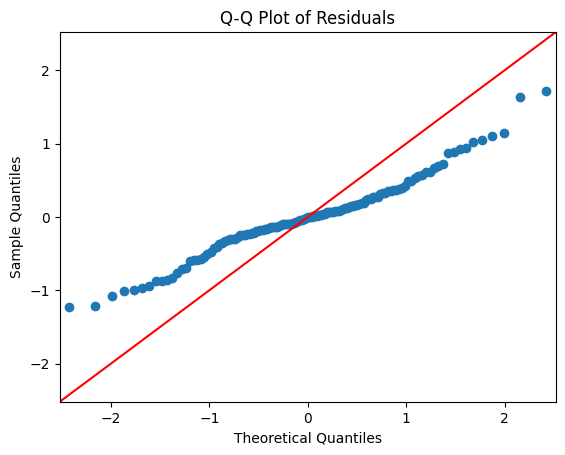

In [20]:
import statsmodels.api as sm
import matplotlib.pyplot as plt 

sm.qqplot(rslt.resid, line='45')
plt.title("Q-Q Plot of Residuals")
plt.show()

#### Residual Plot

The residual plot shows random scatter with no apparent pattern, indicating homoscedasticity. A slight clustering around a fitted value of 1 may require further investigation but does not indicate a severe violation of assumptions.

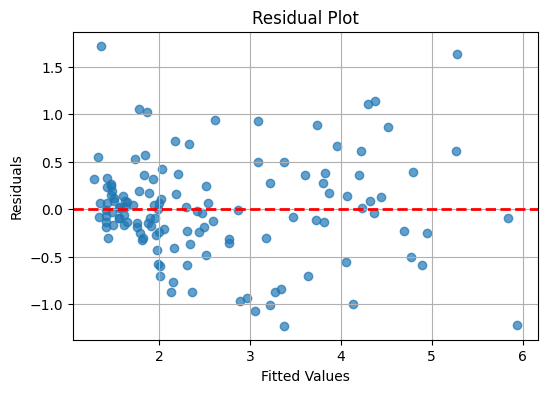

In [21]:
# create dataframe 
df = pd.DataFrame({
    'fitted_values': rslt.fittedvalues,  # Get fitted values
    'residuals': rslt.resid  # Get residuals
})

# create residual plot 
plt.figure(figsize=(6, 4))
plt.scatter(df['fitted_values'], df['residuals'], alpha=0.7)
plt.axhline(0, color='red', linestyle='--', linewidth=2)
plt.title('Residual Plot')
plt.xlabel('Fitted Values'); plt.ylabel('Residuals')

plt.grid(True); plt.show()

#### Variance Inflation Factor (VIF)

Multicollinearity among features can lead to unstable coefficient estimates and hinder model interpretability. This may be an issue in our dataset, as indicated by our PCA analysis.

The Variance Inflation Factor (VIF) is used to quantify multicollinearity, with a common threshold of 10. High VIF values can inflate the significance of predictors, distorting the true effects of the features.

In [22]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# compute the VIF for each feature in the design matrix x
vif_data = pd.DataFrame()
vif_data['Feature'] = x.columns
vif_data['VIF'] = [variance_inflation_factor(x.values, i) for i in range(x.shape[1])]

# display the VIF values
print(vif_data)

               Feature        VIF
0                const   1.000000
1  educ_expected_yrs_f   6.084975
2          life_birthf   8.242011
3                  hdi  15.629728
4                  gdi   2.111264
5           gdp_percap   2.398091
6         immunization   1.863205


We find that `hdi`, `life_birthf`, and `educ_expected_yrs_f` have high VIF scores ranging from 6 to 15, while other variables have moderate to low VIFs. 


##### How should we proceed?

First, let's summarize our findings:

* HDI, education, and life expectancy are highly correlated (0.83-0.93), suggesting that these variables may be capturing similar underlying information.

* These features have high VIF scores that suggest problematic multicollinearity. 

A logical next step would be to remove `hdi` from our model. 

Recall that HDI is a composite measure of health, education, and standard of living, overlapping with other indicators such as education and life expectancy. Removing HDI will address multicollinearity without risking much information loss. The result will be a simpler model that provides a clearer picture of individual effects.

In the next section, we will refine the model by removing `hdi`, recheck VIF for independence, and continue making adjustments as necessary.  

### Model Refinement

First, we will remove `hdi` from the design matrix and recheck VIF to confirm that multicollinearity has been resolved. We will then proceed to build a new OLS model using the remaining predictors, evaluate its performance, and address our research questions based on the results.


In [23]:
# create new design matrix with hdi removed  
dm = data.iloc[:, 1:7]
dm = dm.drop(columns=['hdi'])   # drop hdi 

# normalize features 
dm = (dm - dm.mean()) / dm.std()

# add intercept column (constant 1's)
X = sm.tools.add_constant(dm)

print(X.columns)   # validate hdi has been removed 

Index(['const', 'educ_expected_yrs_f', 'life_birthf', 'gdi', 'gdp_percap',
       'immunization'],
      dtype='object')


In [24]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# recheck VIF 
vif_data = pd.DataFrame()
vif_data['Feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

# display the VIF values
print(vif_data)

               Feature       VIF
0                const  1.000000
1  educ_expected_yrs_f  4.133657
2          life_birthf  4.113814
3                  gdi  2.087899
4           gdp_percap  1.658830
5         immunization  1.808400


It seems like the issue has been resolved! With VIF values all around 1-4, our features no longer exhibit multicollinearity. We are good to proceed onto the next step: building a new OLS model!

Again, the predictors will be standardized with the response in its original units. 

In [25]:
# fit the OLS model
model = sm.OLS(endog=y, exog=X)   # using original response variable y

# store the result
results = model.fit()

# print evaluation metrics
print(f"R-squared: {results.rsquared:.3f}")
print(f"Adjusted R-squared: {results.rsquared_adj:.3f}")
print(f"F-statistic: {results.fvalue:.2f}")
print(f"F-statistic p-value: {results.f_pvalue:.4f}")

R-squared: 0.822
Adjusted R-squared: 0.814
F-statistic: 113.28
F-statistic p-value: 0.0000


Let's analyze these metrics: 

* The R-squared value of 0.822 varies marginally from our old model (0.825), indicating that removing `hdi` had a minimal impact on the model's predictive power.
* A strong adjusted R-squared (0.814) indicates no overfitting as before.
* The new model has a higher F-statistic of 113.28 (vs. 95.69), indicating a stronger fit.

Overall, removing `hdi` improved the model's performance, preserving its predictive power while reducing complexity. 

Next, we turn to address our research questions based on the OLS results.

## Research Questions 

In this section, we will analyze the OLS summary and tackle our research questions. Namely:

* Which factors most predict a country’s fertility rate?
* How do upward mobility, economic prosperity, and child well-being impact fertility rates?
* Which of these explanations are the most probable?

#### Model Results

Recall that the predictors were standardized, but the response variable (fertility) was not. This means the coefficients will be interpreted as the change in the fertility rate (in its original units) for a 1 standard deviation change in each predictor.

The intercept represents the expected fertility rate when all predictors are at their baseline values and is expressed in the original units of fertility.

Keeping those notes in mind, let's analyze the OLS summary. 


In [26]:
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:        fertility_total   R-squared:                       0.822
Model:                            OLS   Adj. R-squared:                  0.814
Method:                 Least Squares   F-statistic:                     113.3
Date:                Wed, 21 May 2025   Prob (F-statistic):           2.57e-44
Time:                        15:29:07   Log-Likelihood:                -101.54
No. Observations:                 129   AIC:                             215.1
Df Residuals:                     123   BIC:                             232.2
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   2.6042    

A larger magnitude of coefficients suggests a stronger association, and a larger t-value (smaller p-value) indicates statistical significance. 

Interpretation: 

* The intercept (const) of 2.6042 represents the expected fertility rate when all predictors are at their baseline, approximately 2.6 children per woman. 
* A 1 unit standard deviation increase in female education decreases fertility rates by 0.5132 units. 
* A 1 unit standard deviation increase in life expectancy decreases fertility rates by 0.6648 units.  
* GDI, GDP per capita, and immunization show weakly associations with fertility rates and are not statistically significant (p > 0.05). 

Key findings: 

* The strongest predictors are education and life expectancy, both of which are statistically significant (p < 0.05). These factors are negatively associated with fertility rates, supporting the child well-being argument 
* Other predictors, such as GDI, GDP per capita, and immunization have weak correlations with fertility rates and lack predictive power. 


Now, we turn to address our research questions.

#### Which factors most predict a country’s fertility rate? 

The most significant predictors of a country's fertility rate are education and life expectancy, both of which show negative associations with fertility rates. 

This suggests that higher female education is linked to lower fertility, likely due to delayed childbearing, career pursuits, and improved access to family planning.

Longer life expectancy also correlates with lower fertility, supporting the child well-being argument, where parents invest more in each child's well-being and survival in healthier countries.

#### How do upward mobility, economic prosperity, and child well-being impact fertility rates?


Upward mobility (proxied by education) is associated with lower fertility as women pursue education and careers, delaying childbearing. 

Economic prosperity (proxied by GDP and GDI) showed weak associations with fertility rates. This suggests that other factors like income distribution or social safety nets may be more relevant for fertility, rather than GDP alone.

Child well-being (proxied by life expectancy) negatively correlates with fertility rates. This suggests that better health outcomes are associated with lower fertility, as families invest more in fewer children with higher quality of life.

#### Which explanations are most probable?


The most probable explanations for fertility rate variations are education and life expectancy. Education, through upward mobility, is linked to lower fertility as women delay childbearing. Life expectancy, a proxy for child well-being, also correlates with lower fertility. 

GDP per capita has little impact, while gdi supports the upward mobility argument, indicating that gender development may play a role in fertility decisions.

## Conclusion

This project examined the decline in fertility rates across select countries using data from 2018. Due to the relatively small dataset and presence of unrelated features, we first tidied the data and performed exploratory analysis to uncover patterns. Variation in the data was assessed through correlation analysis and principal component analysis (PCA), followed by the development, refinement, and evaluation of a multiple regression model.

Our analysis revealed that both improvements in well-being and increased social mobility for women are negatively associated with fertility rates.

We acknowledge several limitations: the complexity of the research questions and the time constraints. The fertility rate is highly variable, and our model's susceptibility to noise prevented us from fully capturing all influencing factors. Additionally, focusing solely on 2018 data restricted our scope. 

Future work could include additional variables, address missing data, and apply more robust models. Exploring complex models and time-series analysis could help account for temporal variations and autocorrelation, providing a clearer picture of fertility trends.